=== 地理范围信息 ===
最小经度 (minx): 118.357941
最大经度 (maxx): 119.226601
最小纬度 (miny): 31.231651
最大纬度 (maxy): 32.615547

=== 范围大小估算 ===
东西方向宽度: 96.42 km
南北方向高度: 153.61 km
覆盖面积估算: 14811.50 km²

=== 数据基本信息 ===
要素数量: 496744
坐标系统: EPSG:4326
属性字段: ['highway', 'length', 'width', 'geometry']


d:\STUDY\anaconda\envs\rpslums\lib\site-packages\geopandas\plotting.py:489: UserWarning: Glyph 32428 (\N{CJK UNIFIED IDEOGRAPH-7EAC}) missing from current font.
  plt.draw()
d:\STUDY\anaconda\envs\rpslums\lib\site-packages\geopandas\plotting.py:489: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from current font.
  plt.draw()
d:\STUDY\anaconda\envs\rpslums\lib\site-packages\geopandas\plotting.py:489: UserWarning: Glyph 22320 (\N{CJK UNIFIED IDEOGRAPH-5730}) missing from current font.
  plt.draw()
d:\STUDY\anaconda\envs\rpslums\lib\site-packages\geopandas\plotting.py:489: UserWarning: Glyph 29702 (\N{CJK UNIFIED IDEOGRAPH-7406}) missing from current font.
  plt.draw()
d:\STUDY\anaconda\envs\rpslums\lib\site-packages\geopandas\plotting.py:489: UserWarning: Glyph 33539 (\N{CJK UNIFIED IDEOGRAPH-8303}) missing from current font.
  plt.draw()
d:\STUDY\anaconda\envs\rpslums\lib\site-packages\geopandas\plotting.py:489: UserWarning: Glyph 22260 (\N{CJK UNIFIED IDEOGRAPH-56F

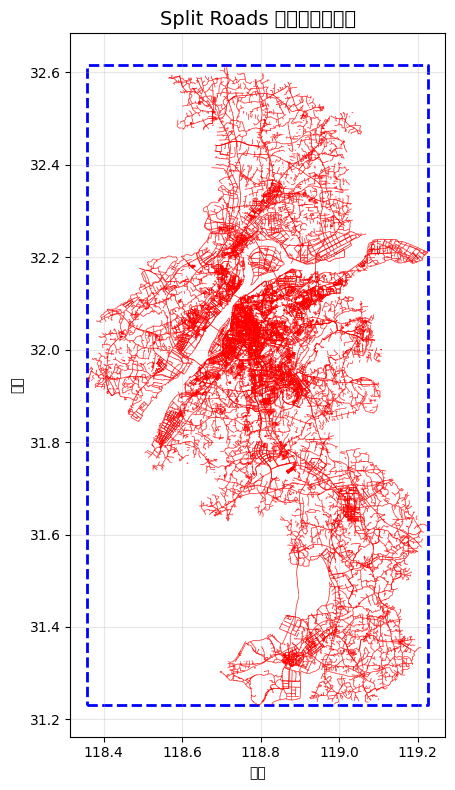

In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 读取split_roads.shp文件
split_roads = gpd.read_file('split_roads.shp')

# 获取地理范围
bounds = split_roads.bounds

print("=== 地理范围信息 ===")
print(f"最小经度 (minx): {bounds['minx'].min():.6f}")
print(f"最大经度 (maxx): {bounds['maxx'].max():.6f}")
print(f"最小纬度 (miny): {bounds['miny'].min():.6f}")
print(f"最大纬度 (maxy): {bounds['maxy'].max():.6f}")

# 计算范围大小（粗略估算）
width_km = (bounds['maxx'].max() - bounds['minx'].min()) * 111
height_km = (bounds['maxy'].max() - bounds['miny'].min()) * 111

print(f"\n=== 范围大小估算 ===")
print(f"东西方向宽度: {width_km:.2f} km")
print(f"南北方向高度: {height_km:.2f} km")
print(f"覆盖面积估算: {width_km * height_km:.2f} km²")

# 显示数据基本信息
print(f"\n=== 数据基本信息 ===")
print(f"要素数量: {len(split_roads)}")
print(f"坐标系统: {split_roads.crs}")
print(f"属性字段: {list(split_roads.columns)}")

# 可视化地理范围
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
split_roads.plot(ax=ax, color='red', linewidth=0.5)
ax.set_title('Split Roads 地理范围可视化', fontsize=14)
ax.set_xlabel('经度')
ax.set_ylabel('纬度')
ax.grid(True, alpha=0.3)

# 添加边界框
bounds_polygon = gpd.GeoDataFrame(
    geometry=[split_roads.unary_union.envelope],
    crs=split_roads.crs
)
bounds_polygon.plot(ax=ax, facecolor='none', edgecolor='blue', linewidth=2, linestyle='--')

plt.tight_layout()
plt.show()

=== 原始边界 ===
经度范围: 118.357941 到 119.226601
纬度范围: 31.231651 到 32.615547

=== 裁剪后边界 ===
经度范围: 118.575106 到 119.009436
纬度范围: 31.923599 到 32.154249

=== 裁剪结果 ===
原始道路数量: 496744
裁剪后道路数量: 207822
裁剪后的道路数据已保存为 test_roads.shp


d:\STUDY\anaconda\envs\rpslums\lib\site-packages\geopandas\plotting.py:489: UserWarning: Glyph 32428 (\N{CJK UNIFIED IDEOGRAPH-7EAC}) missing from current font.
  plt.draw()
d:\STUDY\anaconda\envs\rpslums\lib\site-packages\geopandas\plotting.py:489: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from current font.
  plt.draw()
d:\STUDY\anaconda\envs\rpslums\lib\site-packages\geopandas\plotting.py:489: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from current font.
  plt.draw()
d:\STUDY\anaconda\envs\rpslums\lib\site-packages\geopandas\plotting.py:489: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from current font.
  plt.draw()
d:\STUDY\anaconda\envs\rpslums\lib\site-packages\geopandas\plotting.py:489: UserWarning: Glyph 36947 (\N{CJK UNIFIED IDEOGRAPH-9053}) missing from current font.
  plt.draw()
d:\STUDY\anaconda\envs\rpslums\lib\site-packages\geopandas\plotting.py:489: UserWarning: Glyph 36335 (\N{CJK UNIFIED IDEOGRAPH-8DE

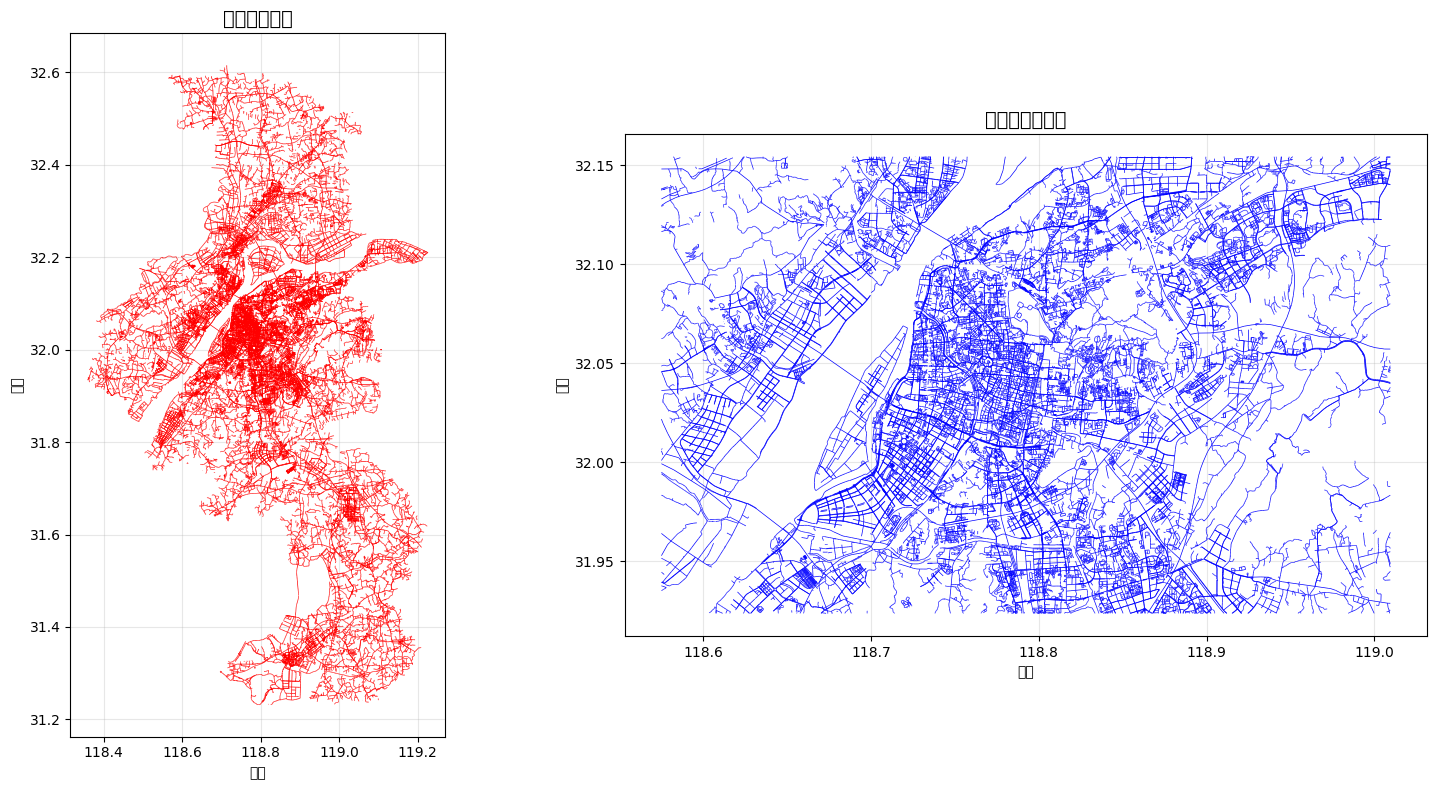


=== 裁剪后数据信息 ===
数据形状: (207822, 4)
坐标系统: EPSG:4326
属性字段: ['highway', 'length', 'width', 'geometry']

=== 裁剪后数据边界 ===
最小经度: 118.575106
最大经度: 119.009436
最小纬度: 31.923599
最大纬度: 32.154249


In [6]:
import geopandas as gpd
from shapely.geometry import box

# 读取split_roads.shp文件
split_roads = gpd.read_file('split_roads.shp')

# 获取原始边界
bounds = split_roads.bounds
minx, maxx = bounds['minx'].min(), bounds['maxx'].max()
miny, maxy = bounds['miny'].min(), bounds['maxy'].max()

print("=== 原始边界 ===")
print(f"经度范围: {minx:.6f} 到 {maxx:.6f}")
print(f"纬度范围: {miny:.6f} 到 {maxy:.6f}")

# 计算裁剪后的边界
# 东西方向取中间的二分之一
width = maxx - minx
new_minx = minx + width * 0.25  # 从1/4处开始
new_maxx = minx + width * 0.75  # 到3/4处结束

# 南北方向取中间的三分之一
height = maxy - miny
new_miny = miny + height * (1/2)  # 从1/2处开始
new_maxy = miny + height * (2/3)  # 到2/3处结束

print("\n=== 裁剪后边界 ===")
print(f"经度范围: {new_minx:.6f} 到 {new_maxx:.6f}")
print(f"纬度范围: {new_miny:.6f} 到 {new_maxy:.6f}")

# 创建裁剪边界框
clip_box = box(new_minx, new_miny, new_maxx, new_maxy)

# 裁剪道路数据
test_roads = split_roads[split_roads.geometry.intersects(clip_box)].copy()

# 对相交的几何体进行精确裁剪
test_roads['geometry'] = test_roads.geometry.intersection(clip_box)

# 移除空的几何体
test_roads = test_roads[~test_roads.geometry.is_empty]

print(f"\n=== 裁剪结果 ===")
print(f"原始道路数量: {len(split_roads)}")
print(f"裁剪后道路数量: {len(test_roads)}")

# 保存裁剪后的道路数据
test_roads.to_file('test_roads.shp')
print("裁剪后的道路数据已保存为 test_roads.shp")

# 可视化对比
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# 原始数据
split_roads.plot(ax=ax1, color='red', linewidth=0.5)
ax1.set_title('原始道路数据', fontsize=14)
ax1.set_xlabel('经度')
ax1.set_ylabel('纬度')
ax1.grid(True, alpha=0.3)

# 裁剪后数据
test_roads.plot(ax=ax2, color='blue', linewidth=0.5)
ax2.set_title('裁剪后道路数据', fontsize=14)
ax2.set_xlabel('经度')
ax2.set_ylabel('纬度')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 显示裁剪后数据的基本信息
print(f"\n=== 裁剪后数据信息 ===")
print(f"数据形状: {test_roads.shape}")
print(f"坐标系统: {test_roads.crs}")
print(f"属性字段: {list(test_roads.columns)}")

# 获取裁剪后数据的边界
test_bounds = test_roads.bounds
print(f"\n=== 裁剪后数据边界 ===")
print(f"最小经度: {test_bounds['minx'].min():.6f}")
print(f"最大经度: {test_bounds['maxx'].max():.6f}")
print(f"最小纬度: {test_bounds['miny'].min():.6f}")
print(f"最大纬度: {test_bounds['maxy'].max():.6f}")